In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import polyfit
from scipy.stats import gaussian_kde

In [ ]:
OBS = '../02_data/2026-05-28/compendium/qwen/qwen'

In [4]:
results = {}

for id in os.listdir(OBS):
    if id == '.DS_Store':
        continue
    
    info = id.split('_')
    retriever = info[3]

    df = pd.read_json(f"{OBS}/{id}/results.jsonl", orient='records', lines=True)
    results[f"{retriever}"] = df

In [6]:
print('Retriever Success (recall@10 ± std)')
for k in results.keys():
    recall_10 = results[k]['retriever_recall@10'].mean()
    recall_std = results[k]['retriever_recall@10'].std()

    print(f"{k:10} {recall_10:.2f} ±{recall_std:.4f}")

Retriever Success (recall@10 ± std)
hybrid     0.50 ±0.3289
oracle     0.98 ±0.0845
dense      0.52 ±0.3297
sparse     0.38 ±0.3270
empty      0.00 ±0.0000


In [7]:
print('Abstained')
for k in results.keys():
    df = results[k]
    df['abstain_cleaned'] = df['generated_answer'].apply(lambda g: 'I DO NOT KNOW' in g)

    recall_10 = df['abstain_cleaned'].mean()
    recall_std = df['abstain_cleaned'].std()

    print(f"{k:10} {recall_10:.2f} ±{recall_std:.4f}")

Abstained
hybrid     0.02 ±0.1283
oracle     0.03 ±0.1565
dense      0.01 ±0.1076
sparse     0.06 ±0.2285
empty      0.87 ±0.3352


In [8]:
def get_task_success(eval):
    return (eval['correctness_accuracy'] + eval['completeness_accuracy'] + eval['focus_accuracy']) / 3

print('Task Success (CheckEval)')
for k in results.keys():
    df = results[k]
    df['task_success_calc'] = df['task_success_score']/10

    recall_10 = df['task_success_calc'].mean()
    recall_std = df['task_success_calc'].std()

    print(f"{k:10} {recall_10:.2f} ±{recall_std:.4f}")

Task Success (CheckEval)
hybrid     0.47 ±0.2464
oracle     0.59 ±0.2324
dense      0.49 ±0.2384
sparse     0.42 ±0.2622
empty      0.38 ±0.1241


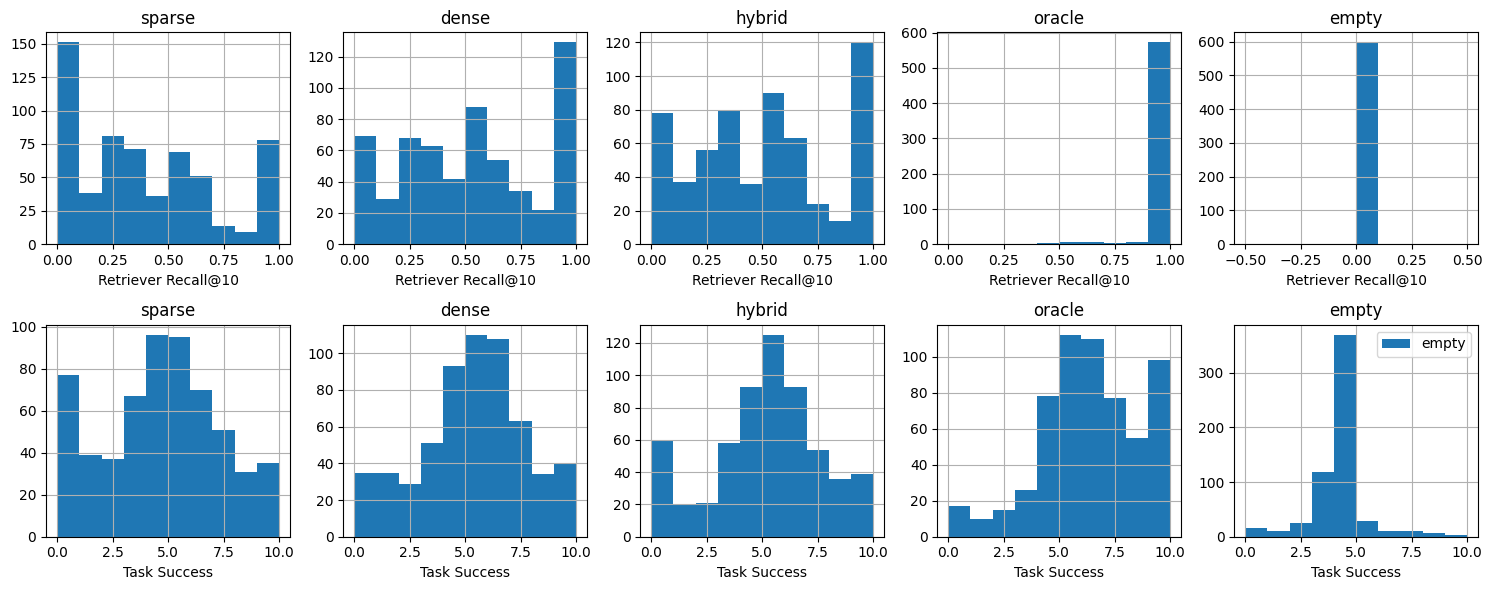

In [9]:

i = 0
fig, axs = plt.subplots(2, 5, figsize=(15,6))


for k in ['sparse', 'dense', 'hybrid', 'oracle', 'empty']:
    ax = axs[0][i]
    df = results[k]
    x = df['retriever_recall@10']
    ax.hist(x, bins=10, label=k)
    ax.grid()
    ax.set_title(k)
    ax.set_xlabel('Retriever Recall@10')

    ax = axs[1][i]
    df = results[k]
    y = df['task_success_score']
    ax.hist(y, bins=10, label=k)
    ax.grid()
    ax.set_title(k)
    ax.set_xlabel('Task Success')

    i+=1

plt.tight_layout()
plt.legend()
plt.show()

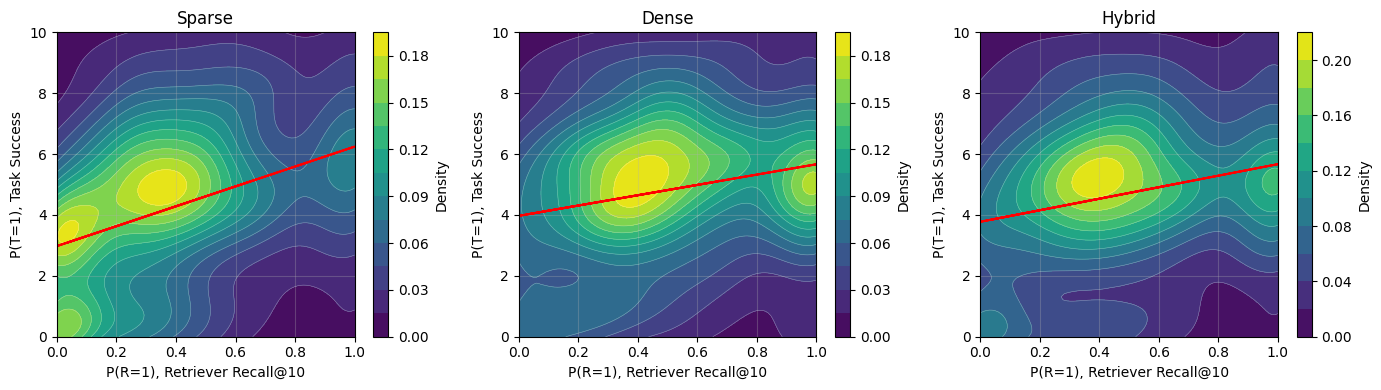

In [ ]:
i = 0
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

for k in ['sparse', 'dense', 'hybrid']:
    ax = axs[i]
    df = results[k]
    x = df['retriever_recall@10']
    y = df['task_success_score']

    # Create a grid to evaluate the KDE on
    x_grid = np.linspace(x.min(), x.max(), 100)
    y_grid = np.linspace(y.min(), y.max(), 100)
    xx, yy = np.meshgrid(x_grid, y_grid)

    # Evaluate KDE on the grid
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

    # Fit line
    b, m = polyfit(x, y, 1)

    cf = ax.contourf(xx, yy, zz, levels=12, cmap='viridis')
    ax.contour(xx, yy, zz, levels=12, colors='white', linewidths=0.4, alpha=0.4)
    fig.colorbar(cf, ax=ax, label='Density')

    ax.plot(x, b + m * x, color='red', linewidth=1.5, label=k)
    ax.set_title(k.capitalize())
    ax.set_xlabel('P(R=1), Retriever Recall@10')
    ax.set_ylabel('P(T=1), Task Success')
    ax.grid(alpha=0.3)

    i += 1

plt.tight_layout()
plt.show()